# Dataset Distribution — Test vs Non-Test
Analyses the raw MainDataset (before any splitting) and compares:
- Image counts for test-prefix vs non-test-prefix images
- Per-class annotation counts and ratios for each group
- Annotation density (objects per image) per group

In [ ]:
import os
import sys
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, os.path.abspath('.'))
from plot_config import apply_style, COLORS, FIGSIZE_MULTI, FIGSIZE_WIDE, FIGSIZE_SINGLE
apply_style()

# ── Config ──────────────────────────────────────────────────────────────────
DATASET_DIR = r'C:\Users\rajcr\Desktop\Study\MTech\Courses\CV\Project\Dataset\MainDataset\train'
IMAGES_DIR  = os.path.join(DATASET_DIR, 'images')
LABELS_DIR  = os.path.join(DATASET_DIR, 'labels')

# Prefixes that identify test images (case-insensitive startswith match)
TEST_PREFIXES = ['test']

CLASS_NAMES = {0: 'bike', 1: 'helmet', 2: 'no-helmet', 3: 'number-plate'}
print(f'Images dir : {IMAGES_DIR}')
print(f'Labels dir : {LABELS_DIR}')

Images dir : C:\Users\rajcr\Desktop\Study\MTech\Courses\CV\Project\Dataset\leaked_data_split\images
Labels dir : C:\Users\rajcr\Desktop\Study\MTech\Courses\CV\Project\Dataset\leaked_data_split\labels


In [22]:
def is_test(filename: str) -> bool:
    name = filename.lower()
    return any(name.startswith(p) for p in TEST_PREFIXES)

def parse_label(label_path: str) -> list:
    """Return list of class ids from a YOLO label file."""
    if not os.path.exists(label_path):
        return []
    classes = []
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                classes.append(int(parts[0]))
    return classes

# ── Load all images and their annotations ────────────────────────────────────
all_images = sorted(f for f in os.listdir(IMAGES_DIR) if f.lower().endswith('.jpg'))

records = []   # list of dicts: {filename, group, classes}
for img in all_images:
    label_path = os.path.join(LABELS_DIR, os.path.splitext(img)[0] + '.txt')
    classes = parse_label(label_path)
    records.append({
        'filename': img,
        'group': 'test' if is_test(img) else 'non-test',
        'classes': classes,
        'n_objects': len(classes),
    })

test_records     = [r for r in records if r['group'] == 'test']
nontests_records = [r for r in records if r['group'] == 'non-test']

print(f'Total images   : {len(records)}')
print(f'  test-prefix  : {len(test_records)}  ({100*len(test_records)/len(records):.1f}%)')
print(f'  non-test     : {len(nontests_records)}  ({100*len(nontests_records)/len(records):.1f}%)')

Total images   : 6520
  test-prefix  : 1022  (15.7%)
  non-test     : 5498  (84.3%)


## 1. Image Count Distribution

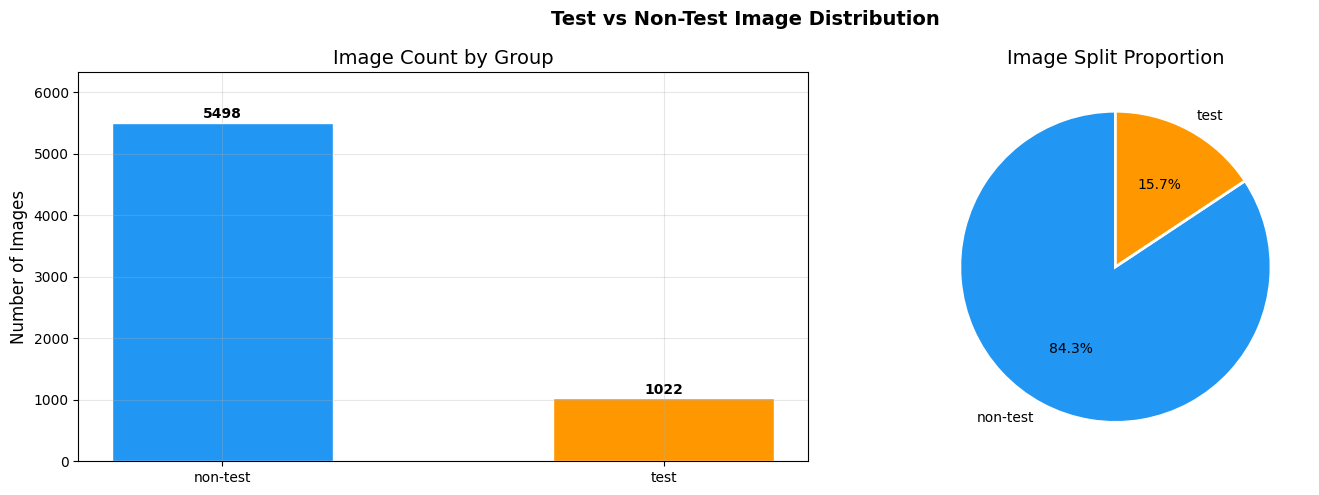

In [23]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_MULTI)

# Bar chart
groups  = ['non-test', 'test']
counts  = [len(nontests_records), len(test_records)]
bar_colors = ['#2196F3', '#FF9800']
bars = axes[0].bar(groups, counts, color=bar_colors, width=0.5, edgecolor='white')
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(count), ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Image Count by Group')
axes[0].set_ylabel('Number of Images')
axes[0].set_ylim(0, max(counts) * 1.15)

# Pie chart
axes[1].pie(counts, labels=groups, colors=bar_colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Image Split Proportion')

plt.suptitle('Test vs Non-Test Image Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Per-Class Annotation Counts

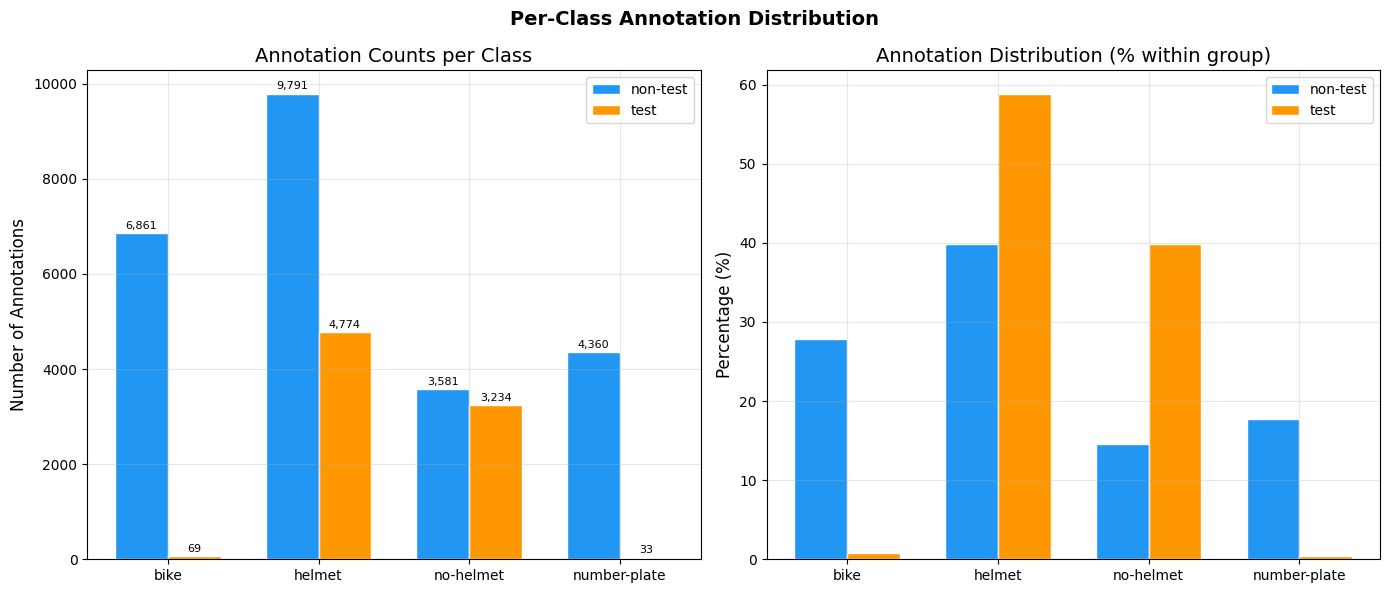

Class            non-test count   non-test %   test count     test %
--------------------------------------------------------------------
bike                      6,861        27.9%           69       0.9%
helmet                    9,791        39.8%        4,774      58.9%
no-helmet                 3,581        14.6%        3,234      39.9%
number-plate              4,360        17.7%           33       0.4%
--------------------------------------------------------------------
TOTAL                    24,593       100.0%        8,110     100.0%


In [24]:
def class_counts(records_list):
    counts = defaultdict(int)
    for r in records_list:
        for cls in r['classes']:
            counts[cls] += 1
    return counts

test_cls     = class_counts(test_records)
nontest_cls  = class_counts(nontests_records)

class_ids   = sorted(CLASS_NAMES.keys())
class_labels = [CLASS_NAMES[i] for i in class_ids]
test_vals    = [test_cls.get(i, 0)    for i in class_ids]
nontest_vals = [nontest_cls.get(i, 0) for i in class_ids]

x = np.arange(len(class_ids))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Grouped bar — absolute counts
b1 = axes[0].bar(x - width/2, nontest_vals, width, label='non-test', color='#2196F3', edgecolor='white')
b2 = axes[0].bar(x + width/2, test_vals,    width, label='test',     color='#FF9800', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_labels)
axes[0].set_title('Annotation Counts per Class')
axes[0].set_ylabel('Number of Annotations')
axes[0].legend()
for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 50,
                     f'{h:,}', ha='center', va='bottom', fontsize=8)

# Normalised (% within group)
nontest_total = sum(nontest_vals) or 1
test_total    = sum(test_vals)    or 1
nontest_pct   = [v / nontest_total * 100 for v in nontest_vals]
test_pct      = [v / test_total    * 100 for v in test_vals]

axes[1].bar(x - width/2, nontest_pct, width, label='non-test', color='#2196F3', edgecolor='white')
axes[1].bar(x + width/2, test_pct,    width, label='test',     color='#FF9800', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_labels)
axes[1].set_title('Annotation Distribution (% within group)')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend()

plt.suptitle('Per-Class Annotation Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
print(f'{'Class':<15} {'non-test count':>15} {'non-test %':>12} {'test count':>12} {'test %':>10}')
print('-' * 68)
for i, name in CLASS_NAMES.items():
    nt = nontest_cls.get(i, 0)
    t  = test_cls.get(i, 0)
    print(f'{name:<15} {nt:>15,} {nt/nontest_total*100:>11.1f}% {t:>12,} {t/test_total*100:>9.1f}%')
print('-' * 68)
print(f'{'TOTAL':<15} {nontest_total:>15,} {'100.0':>11}% {test_total:>12,} {'100.0':>9}%')

## 3. Objects-per-Image Density

C:\Users\rajcr\AppData\Local\Temp\ipykernel_19104\2602259404.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([nontest_density, test_density],


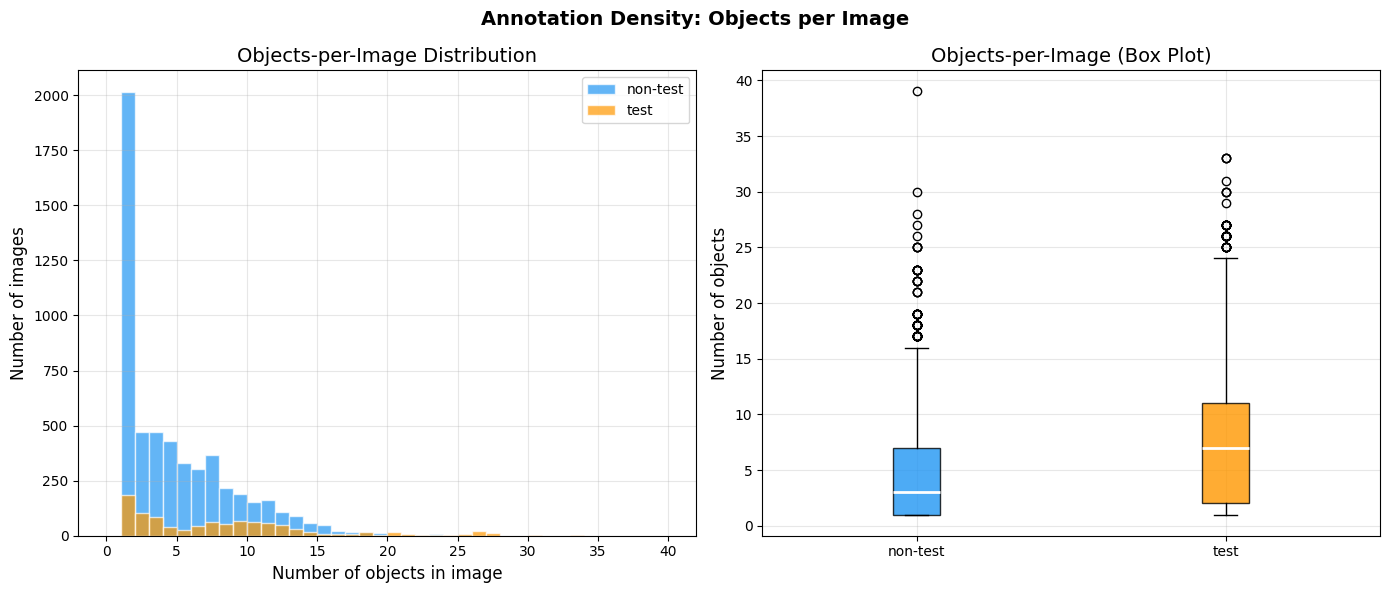

non-test: mean=4.47  median=3.0  min=1  max=39  empty=0
test: mean=7.94  median=7.0  min=1  max=33  empty=0


In [25]:
nontest_density = [r['n_objects'] for r in nontests_records]
test_density    = [r['n_objects'] for r in test_records]

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)

# Histogram
bins = range(0, max(max(nontest_density), max(test_density)) + 2)
axes[0].hist(nontest_density, bins=bins, alpha=0.7, color='#2196F3', label='non-test', edgecolor='white')
axes[0].hist(test_density,    bins=bins, alpha=0.7, color='#FF9800', label='test',     edgecolor='white')
axes[0].set_title('Objects-per-Image Distribution')
axes[0].set_xlabel('Number of objects in image')
axes[0].set_ylabel('Number of images')
axes[0].legend()

# Box plot
bp = axes[1].boxplot([nontest_density, test_density],
                     labels=['non-test', 'test'],
                     patch_artist=True, notch=False,
                     medianprops={'color': 'white', 'linewidth': 2})
for patch, color in zip(bp['boxes'], ['#2196F3', '#FF9800']):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_title('Objects-per-Image (Box Plot)')
axes[1].set_ylabel('Number of objects')

plt.suptitle('Annotation Density: Objects per Image', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

for name, data in [('non-test', nontest_density), ('test', test_density)]:
    a = np.array(data)
    print(f'{name}: mean={a.mean():.2f}  median={np.median(a):.1f}  '
          f'min={a.min()}  max={a.max()}  empty={int((a==0).sum())}')

## 4. Per-Class Density (avg objects of each class per image)

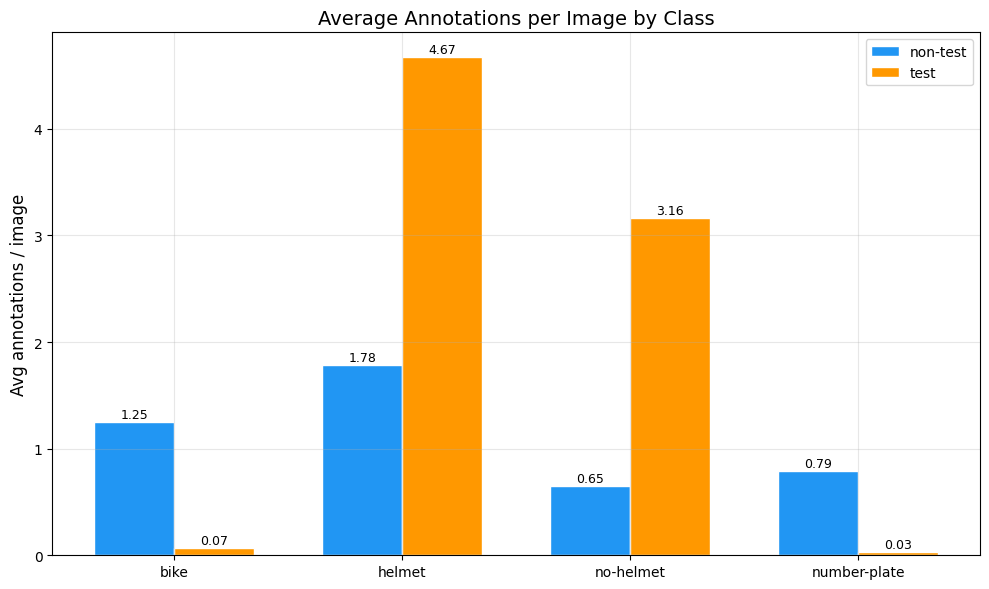

In [26]:
def per_class_density(records_list):
    """Average number of annotations of each class per image."""
    n_imgs = len(records_list) or 1
    counts = defaultdict(int)
    for r in records_list:
        for cls in r['classes']:
            counts[cls] += 1
    return {cls_id: counts[cls_id] / n_imgs for cls_id in CLASS_NAMES}

nt_density = per_class_density(nontests_records)
t_density  = per_class_density(test_records)

nt_d_vals = [nt_density[i] for i in class_ids]
t_d_vals  = [t_density[i]  for i in class_ids]

fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
b1 = ax.bar(x - width/2, nt_d_vals, width, label='non-test', color='#2196F3', edgecolor='white')
b2 = ax.bar(x + width/2, t_d_vals,  width, label='test',     color='#FF9800', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(class_labels)
ax.set_title('Average Annotations per Image by Class')
ax.set_ylabel('Avg annotations / image')
ax.legend()
for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Summary

In [27]:
print('=' * 55)
print('  DATASET SUMMARY')
print('=' * 55)
print(f'  Total images      : {len(records):>6}')
print(f'  non-test images   : {len(nontests_records):>6}  ({100*len(nontests_records)/len(records):.1f}%)')
print(f'  test images       : {len(test_records):>6}  ({100*len(test_records)/len(records):.1f}%)')
print()
print(f'  Total annotations : {nontest_total + test_total:>6}')
print(f'  non-test annots   : {nontest_total:>6}  ({100*nontest_total/(nontest_total+test_total):.1f}%)')
print(f'  test annots       : {test_total:>6}  ({100*test_total/(nontest_total+test_total):.1f}%)')
print()
print(f'  {'Class':<14} non-test  test')
print(f'  {'-'*34}')
for i, name in CLASS_NAMES.items():
    print(f'  {name:<14} {nontest_cls.get(i,0):>7,}  {test_cls.get(i,0):>6,}')
print('=' * 55)

  DATASET SUMMARY
  Total images      :   6520
  non-test images   :   5498  (84.3%)
  test images       :   1022  (15.7%)

  Total annotations :  32703
  non-test annots   :  24593  (75.2%)
  test annots       :   8110  (24.8%)

  Class          non-test  test
  ----------------------------------
  bike             6,861      69
  helmet           9,791   4,774
  no-helmet        3,581   3,234
  number-plate     4,360      33


## 6. Frame-Prefix Images — Object Distribution & Dataset Contribution

Prefix inspected : 'frame'
Images matched   : 1,515  (23.2% of dataset)
Annotations      : 9,951  (30.4% of all annotations)



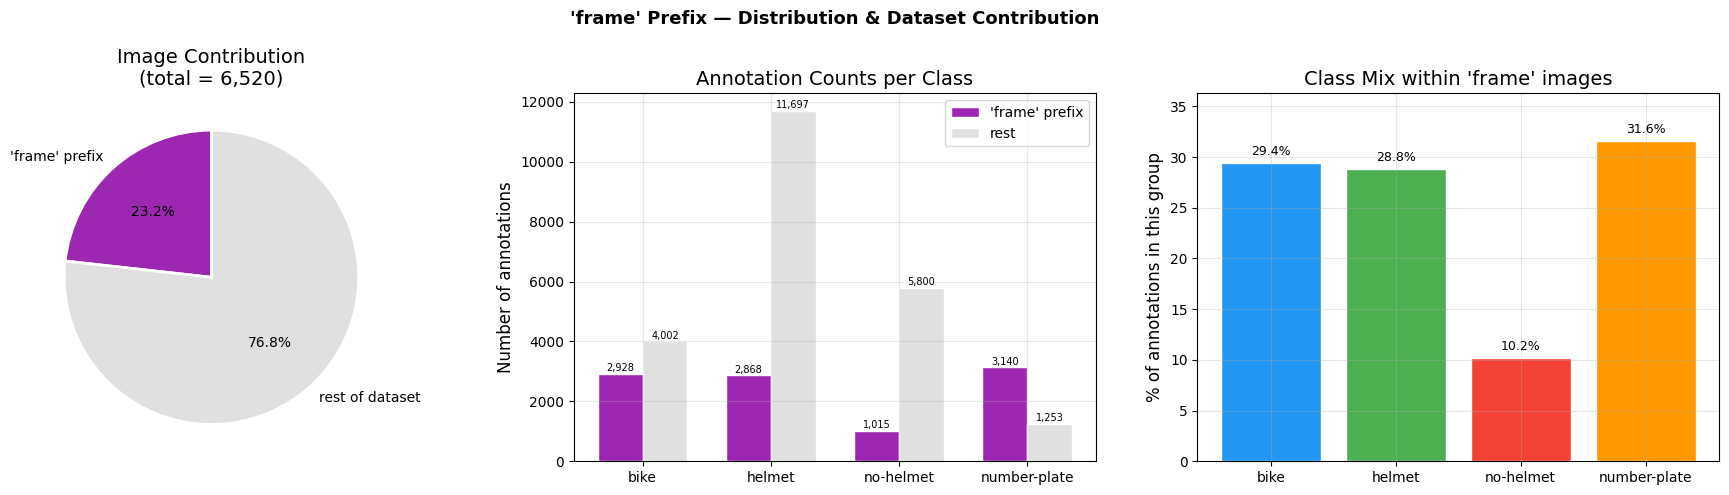

Class            frame count   % of frame  % of all annots
----------------------------------------------------------
bike                   2,928        29.4%             9.0%
helmet                 2,868        28.8%             8.8%
no-helmet              1,015        10.2%             3.1%
number-plate           3,140        31.6%             9.6%
----------------------------------------------------------
TOTAL                  9,951       100.0%            30.4%


In [28]:
# ── Change this to inspect any prefix group ──────────────────────────────────
FRAME_PREFIX = 'frame'   # case-insensitive startswith match

# ── Filter records ────────────────────────────────────────────────────────────
frame_records = [r for r in records if r['filename'].lower().startswith(FRAME_PREFIX.lower())]
other_records = [r for r in records if not r['filename'].lower().startswith(FRAME_PREFIX.lower())]

n_total  = len(records)
n_frame  = len(frame_records)
n_other  = len(other_records)

frame_cls_counts = class_counts(frame_records)
total_annots     = sum(len(r['classes']) for r in records)
frame_annots     = sum(len(r['classes']) for r in frame_records)

print(f"Prefix inspected : '{FRAME_PREFIX}'")
print(f"Images matched   : {n_frame:,}  ({100*n_frame/n_total:.1f}% of dataset)")
print(f"Annotations      : {frame_annots:,}  ({100*frame_annots/total_annots:.1f}% of all annotations)")
print()

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Image contribution pie
axes[0].pie(
    [n_frame, n_other],
    labels=[f"'{FRAME_PREFIX}' prefix", 'rest of dataset'],
    colors=['#9C27B0', '#E0E0E0'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
axes[0].set_title(f"Image Contribution\n(total = {n_total:,})")

# 2. Per-class annotation counts: frame vs rest
rest_cls_counts = class_counts(other_records)
frame_vals = [frame_cls_counts.get(i, 0) for i in class_ids]
rest_vals  = [rest_cls_counts.get(i, 0)  for i in class_ids]

b1 = axes[1].bar(x - width/2, frame_vals, width, label=f"'{FRAME_PREFIX}' prefix",
                 color='#9C27B0', edgecolor='white')
b2 = axes[1].bar(x + width/2, rest_vals,  width, label='rest',
                 color='#E0E0E0', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_labels)
axes[1].set_title('Annotation Counts per Class')
axes[1].set_ylabel('Number of annotations')
axes[1].legend()
for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, h + 20,
                     f'{h:,}', ha='center', va='bottom', fontsize=7)

# 3. Class mix within frame images (normalised %)
frame_total = sum(frame_vals) or 1
frame_pct   = [v / frame_total * 100 for v in frame_vals]
bar_colors_cls = [COLORS[CLASS_NAMES[i]] for i in class_ids]
bars = axes[2].bar(class_labels, frame_pct, color=bar_colors_cls, edgecolor='white')
for bar, pct in zip(bars, frame_pct):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
axes[2].set_title(f"Class Mix within '{FRAME_PREFIX}' images")
axes[2].set_ylabel('% of annotations in this group')
axes[2].set_ylim(0, max(frame_pct) * 1.15)

plt.suptitle(f"'{FRAME_PREFIX}' Prefix — Distribution & Dataset Contribution",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Printed summary ───────────────────────────────────────────────────────────
print(f"{'Class':<15} {'frame count':>12} {'% of frame':>12} {'% of all annots':>16}")
print('-' * 58)
for i, name in CLASS_NAMES.items():
    fc = frame_cls_counts.get(i, 0)
    print(f"{name:<15} {fc:>12,} {fc/frame_total*100:>11.1f}% {fc/total_annots*100:>15.1f}%")
print('-' * 58)
print(f"{'TOTAL':<15} {frame_total:>12,} {'100.0':>11}% {frame_total/total_annots*100:>15.1f}%")


Prefix inspected : 'helmetimage'
Images matched   : 266  (4.1% of dataset)
Annotations      : 306  (0.9% of all annotations)



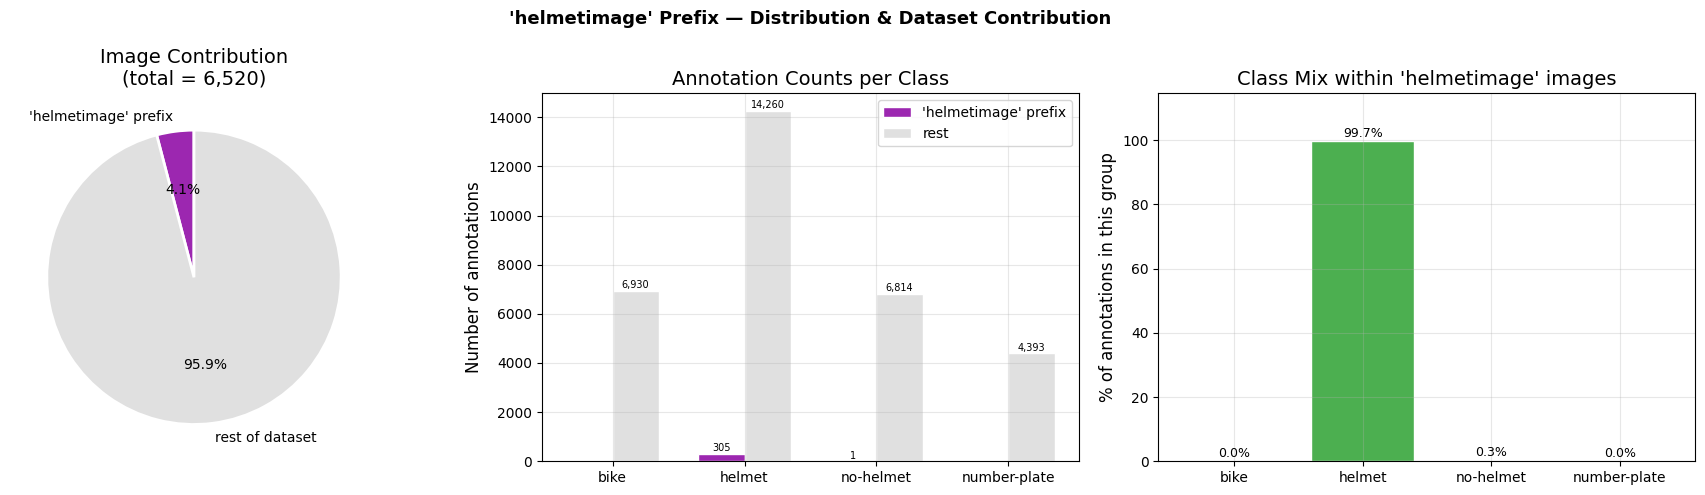

Class            frame count   % of frame  % of all annots
----------------------------------------------------------
bike                       0         0.0%             0.0%
helmet                   305        99.7%             0.9%
no-helmet                  1         0.3%             0.0%
number-plate               0         0.0%             0.0%
----------------------------------------------------------
TOTAL                    306       100.0%             0.9%


In [29]:
# ── Change this to inspect any prefix group ──────────────────────────────────
FRAME_PREFIX = 'helmetimage'   # case-insensitive startswith match

# ── Filter records ────────────────────────────────────────────────────────────
frame_records = [r for r in records if r['filename'].lower().startswith(FRAME_PREFIX.lower())]
other_records = [r for r in records if not r['filename'].lower().startswith(FRAME_PREFIX.lower())]

n_total  = len(records)
n_frame  = len(frame_records)
n_other  = len(other_records)

frame_cls_counts = class_counts(frame_records)
total_annots     = sum(len(r['classes']) for r in records)
frame_annots     = sum(len(r['classes']) for r in frame_records)

print(f"Prefix inspected : '{FRAME_PREFIX}'")
print(f"Images matched   : {n_frame:,}  ({100*n_frame/n_total:.1f}% of dataset)")
print(f"Annotations      : {frame_annots:,}  ({100*frame_annots/total_annots:.1f}% of all annotations)")
print()

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Image contribution pie
axes[0].pie(
    [n_frame, n_other],
    labels=[f"'{FRAME_PREFIX}' prefix", 'rest of dataset'],
    colors=['#9C27B0', '#E0E0E0'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
axes[0].set_title(f"Image Contribution\n(total = {n_total:,})")

# 2. Per-class annotation counts: frame vs rest
rest_cls_counts = class_counts(other_records)
frame_vals = [frame_cls_counts.get(i, 0) for i in class_ids]
rest_vals  = [rest_cls_counts.get(i, 0)  for i in class_ids]

b1 = axes[1].bar(x - width/2, frame_vals, width, label=f"'{FRAME_PREFIX}' prefix",
                 color='#9C27B0', edgecolor='white')
b2 = axes[1].bar(x + width/2, rest_vals,  width, label='rest',
                 color='#E0E0E0', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_labels)
axes[1].set_title('Annotation Counts per Class')
axes[1].set_ylabel('Number of annotations')
axes[1].legend()
for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, h + 20,
                     f'{h:,}', ha='center', va='bottom', fontsize=7)

# 3. Class mix within frame images (normalised %)
frame_total = sum(frame_vals) or 1
frame_pct   = [v / frame_total * 100 for v in frame_vals]
bar_colors_cls = [COLORS[CLASS_NAMES[i]] for i in class_ids]
bars = axes[2].bar(class_labels, frame_pct, color=bar_colors_cls, edgecolor='white')
for bar, pct in zip(bars, frame_pct):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
axes[2].set_title(f"Class Mix within '{FRAME_PREFIX}' images")
axes[2].set_ylabel('% of annotations in this group')
axes[2].set_ylim(0, max(frame_pct) * 1.15)

plt.suptitle(f"'{FRAME_PREFIX}' Prefix — Distribution & Dataset Contribution",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Printed summary ───────────────────────────────────────────────────────────
print(f"{'Class':<15} {'frame count':>12} {'% of frame':>12} {'% of all annots':>16}")
print('-' * 58)
for i, name in CLASS_NAMES.items():
    fc = frame_cls_counts.get(i, 0)
    print(f"{name:<15} {fc:>12,} {fc/frame_total*100:>11.1f}% {fc/total_annots*100:>15.1f}%")
print('-' * 58)
print(f"{'TOTAL':<15} {frame_total:>12,} {'100.0':>11}% {frame_total/total_annots*100:>15.1f}%")


Prefix inspected : 'hdetect'
Images matched   : 709  (10.9% of dataset)
Annotations      : 5,629  (17.2% of all annotations)



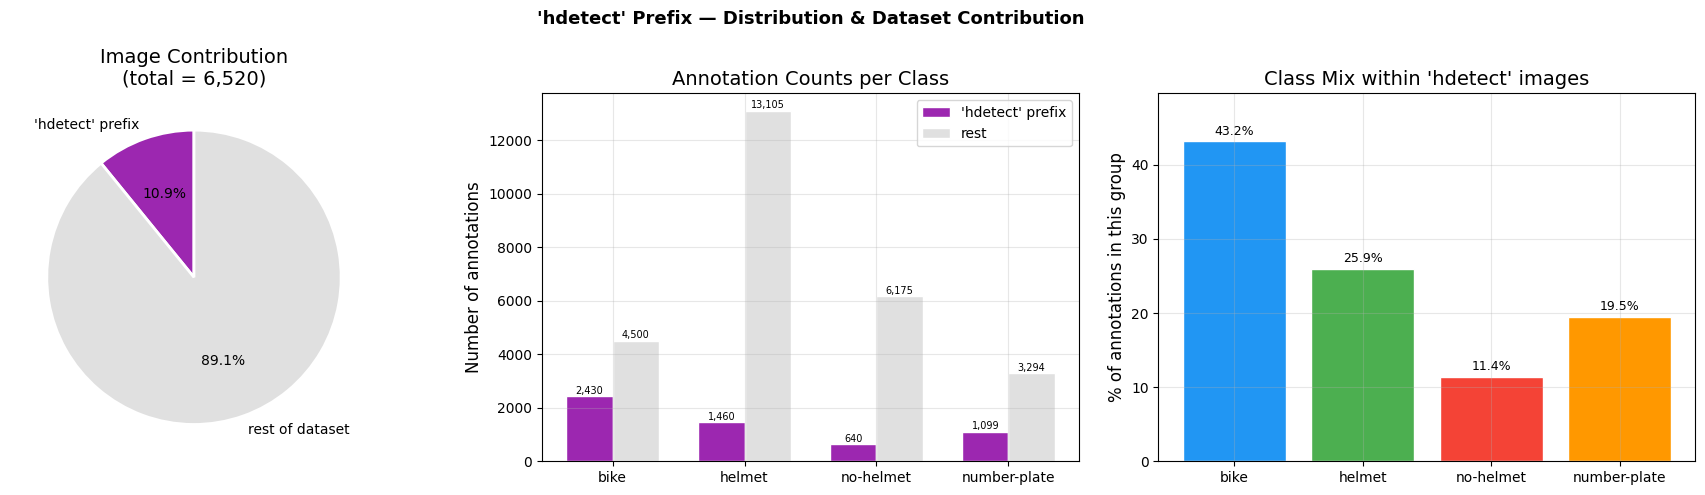

Class            frame count   % of frame  % of all annots
----------------------------------------------------------
bike                   2,430        43.2%             7.4%
helmet                 1,460        25.9%             4.5%
no-helmet                640        11.4%             2.0%
number-plate           1,099        19.5%             3.4%
----------------------------------------------------------
TOTAL                  5,629       100.0%            17.2%


: 

In [ ]:
# ── Change this to inspect any prefix group ──────────────────────────────────
FRAME_PREFIX = 'hdetect'   # case-insensitive startswith match

# ── Filter records ────────────────────────────────────────────────────────────
frame_records = [r for r in records if r['filename'].lower().startswith(FRAME_PREFIX.lower())]
other_records = [r for r in records if not r['filename'].lower().startswith(FRAME_PREFIX.lower())]

n_total  = len(records)
n_frame  = len(frame_records)
n_other  = len(other_records)

frame_cls_counts = class_counts(frame_records)
total_annots     = sum(len(r['classes']) for r in records)
frame_annots     = sum(len(r['classes']) for r in frame_records)

print(f"Prefix inspected : '{FRAME_PREFIX}'")
print(f"Images matched   : {n_frame:,}  ({100*n_frame/n_total:.1f}% of dataset)")
print(f"Annotations      : {frame_annots:,}  ({100*frame_annots/total_annots:.1f}% of all annotations)")
print()

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Image contribution pie
axes[0].pie(
    [n_frame, n_other],
    labels=[f"'{FRAME_PREFIX}' prefix", 'rest of dataset'],
    colors=['#9C27B0', '#E0E0E0'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
axes[0].set_title(f"Image Contribution\n(total = {n_total:,})")

# 2. Per-class annotation counts: frame vs rest
rest_cls_counts = class_counts(other_records)
frame_vals = [frame_cls_counts.get(i, 0) for i in class_ids]
rest_vals  = [rest_cls_counts.get(i, 0)  for i in class_ids]

b1 = axes[1].bar(x - width/2, frame_vals, width, label=f"'{FRAME_PREFIX}' prefix",
                 color='#9C27B0', edgecolor='white')
b2 = axes[1].bar(x + width/2, rest_vals,  width, label='rest',
                 color='#E0E0E0', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_labels)
axes[1].set_title('Annotation Counts per Class')
axes[1].set_ylabel('Number of annotations')
axes[1].legend()
for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, h + 20,
                     f'{h:,}', ha='center', va='bottom', fontsize=7)

# 3. Class mix within frame images (normalised %)
frame_total = sum(frame_vals) or 1
frame_pct   = [v / frame_total * 100 for v in frame_vals]
bar_colors_cls = [COLORS[CLASS_NAMES[i]] for i in class_ids]
bars = axes[2].bar(class_labels, frame_pct, color=bar_colors_cls, edgecolor='white')
for bar, pct in zip(bars, frame_pct):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
axes[2].set_title(f"Class Mix within '{FRAME_PREFIX}' images")
axes[2].set_ylabel('% of annotations in this group')
axes[2].set_ylim(0, max(frame_pct) * 1.15)

plt.suptitle(f"'{FRAME_PREFIX}' Prefix — Distribution & Dataset Contribution",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Printed summary ───────────────────────────────────────────────────────────
print(f"{'Class':<15} {'frame count':>12} {'% of frame':>12} {'% of all annots':>16}")
print('-' * 58)
for i, name in CLASS_NAMES.items():
    fc = frame_cls_counts.get(i, 0)
    print(f"{name:<15} {fc:>12,} {fc/frame_total*100:>11.1f}% {fc/total_annots*100:>15.1f}%")
print('-' * 58)
print(f"{'TOTAL':<15} {frame_total:>12,} {'100.0':>11}% {frame_total/total_annots*100:>15.1f}%")
